In [1]:

import cmdstanpy
import numpy as np
import pandas as pd 
from scipy.special import expit  # inverse logit
import pandas as pd
import numpy as np
from cmdstanpy import CmdStanModel
from joblib import Parallel, delayed

# ---------------------------------------------------------------------
# Assumes df has: participant_id (1..P), sat_int (1..3), rt, correct
# ---------------------------------------------------------------------


In [3]:
df = pd.read_csv("../forstmann.csv")

df["correct"] = df.apply(lambda row: 1 if row["S"] == row["R"] else 0,axis = 1)
df['participant_id'], participant_labels = pd.factorize(df['subjects'])
df['participant_id'] += 1  

sat_map = {"speed":1,"neutral":2,"accuracy":3}
df["sat_int"] = df["E"].map(sat_map)
df["pc"] = (df["participant_id"]-1)*3 + df["sat_int"]
df

,subjects,E,S,R,rt,correct,participant_id,sat_int,pc
0,as1t,accuracy,right,right,0.4319,1,1,3,3
1,as1t,speed,right,right,0.5015,1,1,1,1
2,as1t,speed,left,left,0.3104,1,1,1,1
3,as1t,accuracy,right,right,0.4809,1,1,3,3
4,as1t,accuracy,left,left,0.3415,1,1,3,3
...,...,...,...,...,...,...,...,...,...
15813,zk1t,speed,right,right,0.3244,1,19,1,55
15814,zk1t,neutral,left,left,0.5800,1,19,2,56
15815,zk1t,neutral,left,left,0.9199,1,19,2,56
15816,zk1t,accuracy,left,right,0.6314,0,19,3,57


In [ ]:

model = CmdStanModel(stan_file='SRDM_single_subject.stan')  # compiled once, reused by every worker

def fit_one_participant(pid, df):
    d = df[df['participant_id'] == pid]

    d_correct = d[d['correct'] == 1]
    d_false = d[d['correct'] == 0]

    # per-condition 5th percentile (t0 bound) and max (lapse range), THIS participant only
    t0_hi = d.groupby('sat_int')['rt'].quantile(0.05).reindex([1, 2, 3])
    max_rt = d.groupby('sat_int')['rt'].max().reindex([1, 2, 3])
    assert t0_hi.notna().all() and max_rt.notna().all(), f"participant {pid}: empty condition cell"

    data = {
        'N_correct': len(d_correct),
        'N_false': len(d_false),
        'rt_correct': d_correct['rt'].to_numpy(),
        'rt_false': d_false['rt'].to_numpy(),
        'cond_correct': d_correct['sat_int'].to_numpy(dtype=int),
        'cond_false': d_false['sat_int'].to_numpy(dtype=int),
        'max_rt': max_rt.to_numpy(),
        't0_hi': t0_hi.to_numpy(),
    }

    init_values = {
        'c': [0.0, 0.0, 0.0],
        't0': [0.2, 0.2, 0.2],
        'd': 1.5, 'r': 4.5, 'B': 1.0, 'p_lapse': 0.02,
    }

    fit = model.sample(
        data=data, chains=4, parallel_chains=1,  # 1 here - outer joblib handles the real parallelism
        inits=init_values, iter_warmup=1000, iter_sampling=1000,
        adapt_delta=0.95, show_progress=True,
    )

    summary = fit.summary()
    summary['participant_id'] = pid
    return summary

# run all participants' fits in parallel across CPU cores
results = Parallel(n_jobs=-1)(
    delayed(fit_one_participant)(pid, df) for pid in sorted(df['participant_id'].unique())
)

all_results = pd.concat(results)
all_results.to_csv('per_subject_fits.csv')


16:36:17 - cmdstanpy - INFO - compiling stan file /Users/Anton/Documents/ForskningsprojektSommer2026/ForstmannFit/IndividualStrat/SRDM_single_subject.stan to exe file /Users/Anton/Documents/ForskningsprojektSommer2026/ForstmannFit/IndividualStrat/SRDM_single_subject
16:37:10 - cmdstanpy - INFO - compiled model executable: /Users/Anton/Documents/ForskningsprojektSommer2026/ForstmannFit/IndividualStrat/SRDM_single_subject
16:37:16 - cmdstanpy - INFO - CmdStan start processing
16:37:16 - cmdstanpy - INFO - CmdStan start processing
16:37:16 - cmdstanpy - INFO - CmdStan start processing
16:37:16 - cmdstanpy - INFO - CmdStan start processing
16:37:16 - cmdstanpy - INFO - CmdStan start processing
16:37:16 - cmdstanpy - INFO - CmdStan start processing
16:37:16 - cmdstanpy - INFO - CmdStan start processing
16:37:16 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status



chain 3 |          | 00:00 Status


chain 4 |          | 00:00 S

In [ ]:
N_correct = len(df[df["correct"] == 1])
N_false = len(df[df["correct"] == 0])
P = 19

rt_correct = list(df[df["correct"]==1]["rt"])
rt_false = list(df[df["correct"]==0]["rt"])
pc_correct = list(df[df["correct"]==1]["pc"])
pc_false = list(df[df["correct"]==0]["pc"])

t0_hi = df.groupby('participant_id')['rt'].quantile(0.05).reindex(range(1, P + 1))

max_rt = (
    df.groupby('pc')['rt']
    .max()
    .reindex(range(1, 3 * P + 1))  # was groupby(['participant_id','sat_int']) - fragile, see earlier note
)
assert max_rt.notna().all(), "some cell has zero trials in max_rt"

print(N_correct, N_false, rt_false)

data = {
    "N_correct": N_correct, "N_false": N_false, "P": P,
    "rt_correct": rt_correct, "rt_false": rt_false,
    "pc_correct": pc_correct, "pc_false": pc_false,
    "max_rt": max_rt.to_numpy(), "t0_hi": t0_hi.to_numpy(),
}

from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file='SRDM_hierarchical_d_t0_collapsed.stan')  # <- the r/p_lapse-collapsed version

13294 2524 [0.3111, 0.4118, 0.4343, 0.3286, 0.4872, 0.321, 0.4179, 0.6087, 0.3561, 0.5971, 0.4731, 0.7205, 0.4949, 0.4222, 0.3304, 0.5636, 0.2693, 0.2952, 0.3923, 0.4207, 0.3172, 0.3472, 0.4619, 0.5878, 0.4227, 0.4178, 0.7814, 0.4248, 0.4782, 0.2508, 0.3542, 0.2742, 0.4646, 0.5855, 0.4592, 0.5876, 0.4358, 0.3632, 0.5256, 0.6568, 0.6033, 0.5813, 0.3321, 0.6356, 0.3355, 0.6077, 0.6896, 0.4748, 0.4662, 0.5469, 0.4984, 0.3845, 0.4819, 0.4135, 0.4852, 0.4698, 0.4768, 0.4402, 0.6428, 0.4315, 0.6628, 0.7461, 0.4767, 0.5287, 0.6025, 0.5145, 0.8565, 0.4453, 0.5473, 0.4656, 0.4555, 0.6289, 0.3824, 0.4643, 0.485, 0.301, 0.3467, 0.4999, 0.3045, 0.5888, 0.5423, 0.4593, 0.5522, 0.4058, 0.5459, 0.4679, 0.6829, 0.4227, 0.6181, 0.4917, 0.3587, 0.3434, 0.5736, 0.388, 0.4163, 0.6115, 0.4535, 0.4528, 0.3136, 0.3105, 0.3589, 0.3007, 0.3154, 0.2692, 0.449, 0.3353, 0.3959, 0.4254, 0.4713, 0.5634, 0.3659, 0.369, 0.4745, 0.4393, 0.4981, 0.3239, 0.7392, 0.4319, 0.3065, 0.433, 0.6091, 0.3335, 0.5856, 0.4238, 0.2

In [ ]:
init_values = {
    'mu_c': [0.0]*3, 'sigma_c': [0.3]*3,
    'mu_logB': [0.0]*3, 'sigma_logB': [0.2]*3,
    'mu_logd': np.log(1.5), 'sigma_logd': 0.2,
    'mu_logr': np.log(4.5), 'sigma_logr': 0.2,
    'mu_t0_logit': 0.0, 'sigma_t0_logit': 0.2,
    'mu_lapse_logit': -3.9, 'sigma_lapse_logit': 0.2,
    'c_z': [0.0]*(3*P), 'logB_z': [0.0]*(3*P),
    'logd_z': [0.0]*P, 'logr_z': [0.0]*P, 't0_z': [0.0]*P, 'lapse_z': [0.0]*P,
}

fit = model.sample(data=data, chains=4, parallel_chains=4, inits=init_values,
                    iter_warmup=1500, iter_sampling=1000, adapt_delta=0.9, metric='diag_e')

20:03:43 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:55:42 - cmdstanpy - INFO - CmdStan done processing.


00:55:44 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 3 divergent transitions (0.3%)
	Chain 2 had 1 divergent transitions (0.1%)
	Chain 3 had 1 divergent transitions (0.1%)
	Chain 4 had 3 divergent transitions (0.3%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [ ]:
fit.diagnose()

"Checking sampler transitions treedepth.\nTreedepth satisfactory for all transitions.\n\nChecking sampler transitions for divergences.\n8 of 4000 (0.20%) transitions ended with a divergence.\nThese divergent transitions indicate that HMC is not fully able to explore the posterior distribution.\nTry increasing adapt delta closer to 1.\nIf this doesn't remove all divergences, try to reparameterize the model.\n\nChecking E-BFMI - sampler transitions HMC potential energy.\nE-BFMI satisfactory.\n\nRank-normalized split effective sample size satisfactory for all parameters.\n\nRank-normalized split R-hat values satisfactory for all parameters.\n\nProcessing complete.\n"

In [ ]:
sampler_vars = fit.method_variables()
print(sampler_vars.keys())  # confirms the exact names available

import numpy as np
print("mean treedepth:", np.mean(sampler_vars['treedepth__']))
print("max treedepth used:", np.max(sampler_vars['treedepth__']))
print("mean n_leapfrog:", np.mean(sampler_vars['n_leapfrog__']))
print("fraction at max treedepth (10):", np.mean(sampler_vars['treedepth__'] >= 10))

dict_keys(['lp__', 'accept_stat__', 'stepsize__', 'treedepth__', 'n_leapfrog__', 'divergent__', 'energy__'])
mean treedepth: 7.5745
max treedepth used: 9.0
mean n_leapfrog: 230.41575
fraction at max treedepth (10): 0.0


In [ ]:
import matplotlib.pyplot as plt
import arviz as az
idata = az.from_cmdstanpy(fit)
print(az.summary(idata, var_names=["mu_c", "sigma_c", "mu_logd", "sigma_logd",
                               "mu_logr", "sigma_logr", "mu_logB", "sigma_logB",
                               "mu_t0_logit", "sigma_t0_logit",
                                                              "mu_lapse_logit", "sigma_lapse_logit"]))

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
mu_c[0]           -0.382  0.044  -0.461   -0.297      0.001    0.001   
mu_c[1]           -0.291  0.042  -0.373   -0.215      0.001    0.001   
mu_c[2]           -0.205  0.064  -0.318   -0.074      0.002    0.001   
sigma_c[0]         0.162  0.038   0.099    0.234      0.001    0.001   
sigma_c[1]         0.156  0.037   0.093    0.228      0.001    0.001   
sigma_c[2]         0.256  0.052   0.167    0.354      0.001    0.001   
mu_logd            0.443  0.086   0.269    0.596      0.003    0.002   
sigma_logd         0.333  0.062   0.226    0.447      0.001    0.001   
mu_logr            1.825  0.082   1.680    1.986      0.002    0.001   
sigma_logr         0.152  0.033   0.101    0.216      0.001    0.001   
mu_logB[0]         0.195  0.082   0.045    0.347      0.002    0.001   
mu_logB[1]         0.478  0.072   0.353    0.621      0.002    0.001   
mu_logB[2]         0.530  0.070   0.393    0.658      0.002    0

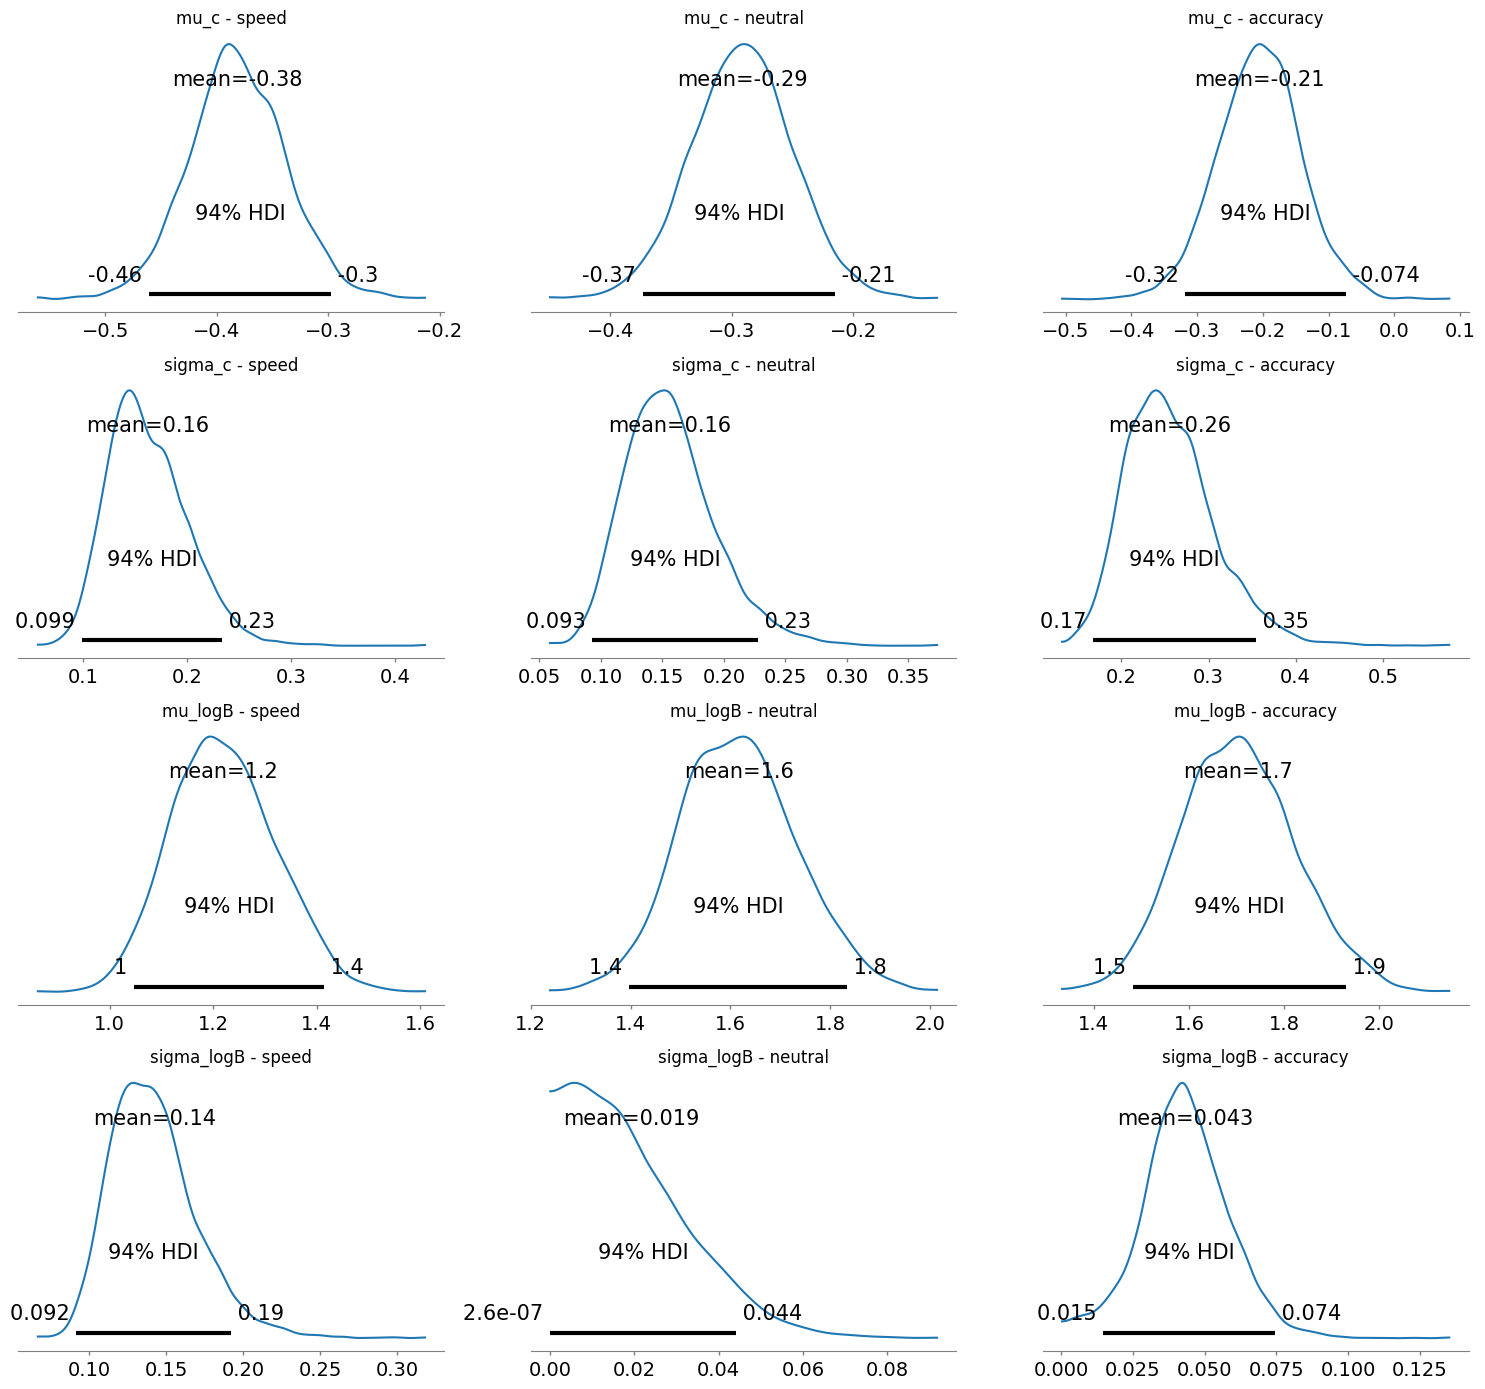

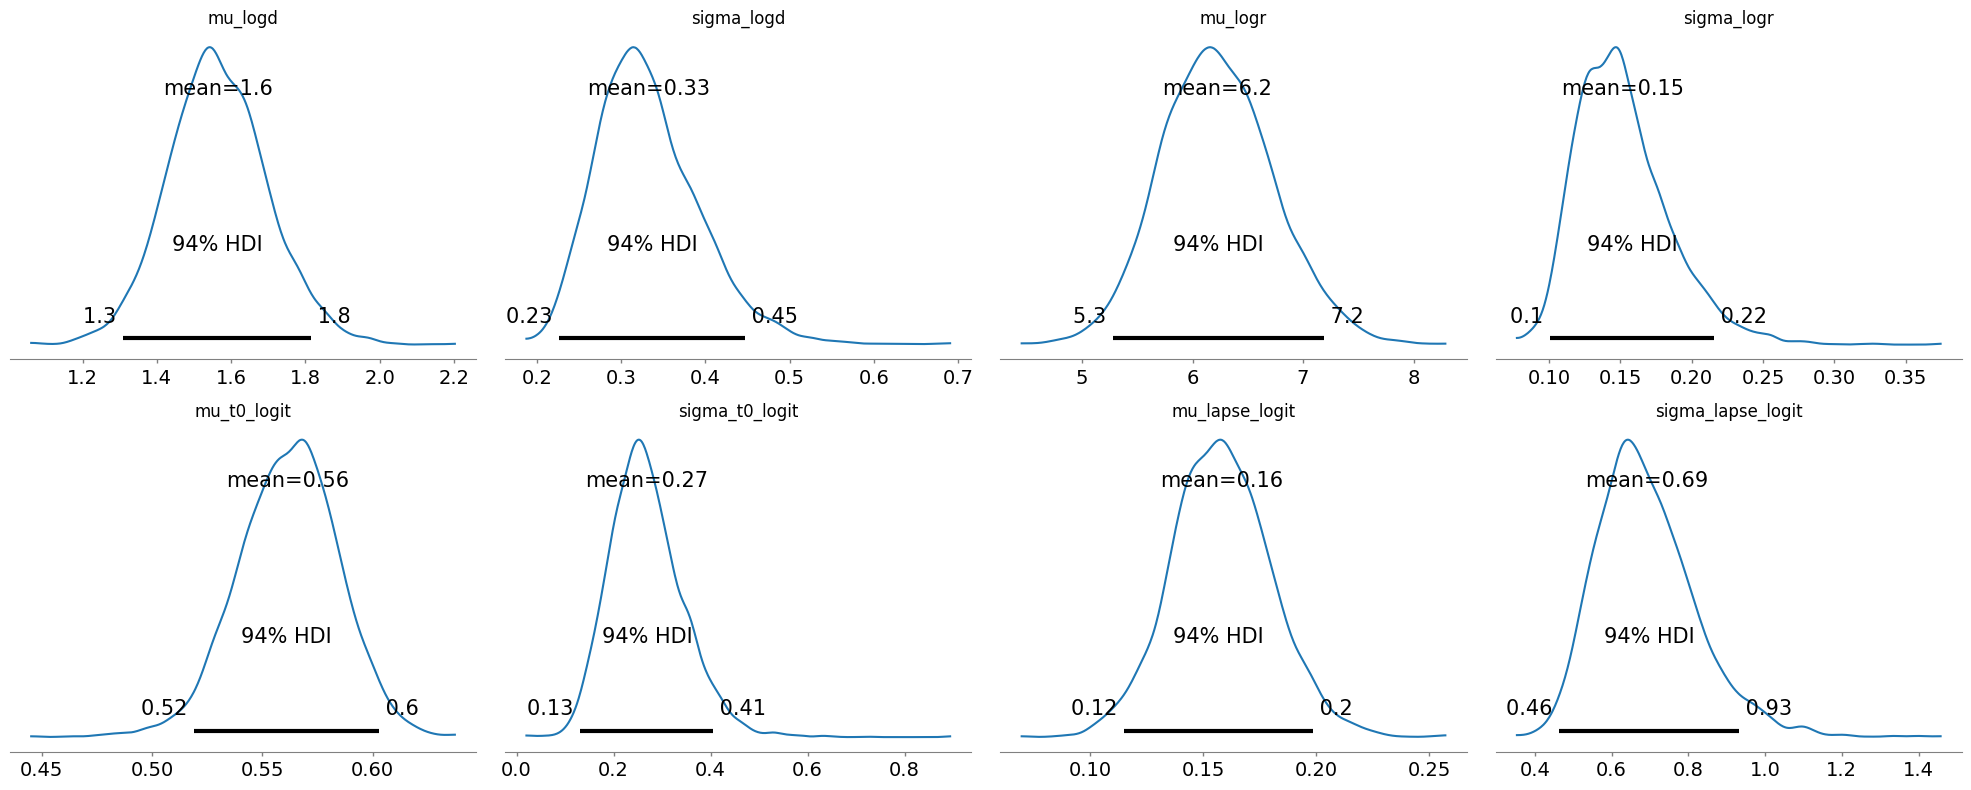

In [ ]:
cond_labels = ["speed", "neutral", "accuracy"]
hyper_pairs_percond = [("mu_c", "sigma_c"), ("mu_logB", "sigma_logB")]
hyper_scalars = [
    ("mu_logd", "sigma_logd"), ("mu_logr", "sigma_logr"),
    ("mu_t0_logit", "sigma_t0_logit"), ("mu_lapse_logit", "sigma_lapse_logit"),
]

transforms = {
    "mu_c": None, "sigma_c": None,
    "mu_logB": np.exp, "sigma_logB": None,
    "mu_logd": np.exp, "sigma_logd": None,
    "mu_logr": np.exp, "sigma_logr": None,
    "mu_t0_logit": expit, "sigma_t0_logit": None,
    "mu_lapse_logit": expit, "sigma_lapse_logit": None,
}

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
row = 0
for mu_var, sigma_var in hyper_pairs_percond:
    for var in (mu_var, sigma_var):
        dim = f"{var}_dim_0"
        for j, cond in enumerate(cond_labels):
            az.plot_posterior(idata, var_names=[var], coords={dim: [j]},
                               transform=transforms[var], ax=axes[row, j])
            axes[row, j].set_title(f"{var} - {cond}")
        row += 1
plt.tight_layout()

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 8))
axes2 = axes2.flatten()
for i, var in enumerate([v for pair in hyper_scalars for v in pair]):
    az.plot_posterior(idata, var_names=[var], transform=transforms[var], ax=axes2[i])
    axes2[i].set_title(var)
plt.tight_layout()
plt.show()

In [ ]:
# in the c/B notebook, after fitting
idata_cB = az.from_cmdstanpy(fit, log_likelihood="log_lik")
idata_cB.to_netcdf("idata_c_B.nc")

'idata_c_B.nc'

In [ ]:
t0_post = idata.posterior["t0"].mean(dim=["chain","draw"]).values  # per participant
t0_post

array([0.1716937 , 0.19403702, 0.19859137, 0.15919874, 0.15647359,
       0.22205301, 0.1836431 , 0.14286381, 0.17537658, 0.18880935,
       0.14225463, 0.16834081, 0.16036223, 0.1944826 , 0.18063133,
       0.20089119, 0.17006047, 0.18116446, 0.16143622])

In [ ]:
import numpy as np

pc_correct_arr = np.array(data['pc_correct'])
pc_false_arr   = np.array(data['pc_false'])

participant_correct = (pc_correct_arr - 1) // 3
cond_correct        = (pc_correct_arr - 1) % 3

forced_lapse = np.array(data['rt_correct']) < t0_post[participant_correct]

for k, name in enumerate(["speed", "neutral", "accuracy"]):
    frac = forced_lapse[cond_correct == k].mean()
    print(f"{name}: {frac:.3%} of correct trials forced into lapse")

speed: 0.000% of correct trials forced into lapse
neutral: 0.000% of correct trials forced into lapse
accuracy: 0.000% of correct trials forced into lapse


In [ ]:
p_lapse_post = idata.posterior["p_lapse"].mean(dim=["chain","draw"]).values
print(np.sort(p_lapse_post))

[0.07635085 0.09108046 0.09317224 0.103093   0.10409467 0.11043518
 0.11110471 0.12634009 0.16392605 0.18110093 0.1846385  0.1870704
 0.18949152 0.19307092 0.2039204  0.24684769 0.27945451 0.3057292
 0.52306618]


In [ ]:
participant_ids = np.argsort(p_lapse_post)[::-1][:3]  # top 3 highest-lapse participants (0-indexed)
worst = participant_ids[1]
mask = df['participant_id'] == (worst + 1)  # adjust for your 1-indexing
print(df[mask]['rt'].describe())
print(df[mask].groupby(['E'])['correct'].mean())  # accuracy per condition for this person

count    810.000000
mean       0.475196
std        0.110809
min        0.250800
25%        0.406025
50%        0.462000
75%        0.532925
max        1.155500
Name: rt, dtype: float64
E
accuracy    0.800000
neutral     0.742958
speed       0.756098
Name: correct, dtype: float64
